# Human vs AI Question/Answer Classification

This artefact explores classification between human written and AI generated text under different classification scenarios, using a self generated dataset.

This includes classifying a single text between AI or Human written, as well as classifying a pair of texts in response to the same question as Human or AI, given that each pair consists of one of each category.

This project also evaluates performance of Human vs AI classification between generative AI models by training with responses given by one generative AI model, but evaluating using responses given by another

# Imports

All additional files are written in the source code for to be added to the Google Drive account which Google Colab is running on, and for the following installations to be completed, with the exception of FastText embeddings which must be downloaded via the download cell in this section, and thereafter uploaded to Google Drive, due to its large size.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [ ]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 4.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498211 sha256=7bdb77f84630774483047ff48dad2634d6c67e9874707f9e94a0cb94655244fc
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
fasttext.util.download_model('en', if_exists='ignore')  # downloads cc.en.300.bin

In [ ]:

# 2. Import necessary libraries
import google.generativeai as genai
import os
import random
from tqdm.notebook import tqdm
import requests
import time
from google.colab import userdata
import pandas as pd
import re
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from openai import OpenAI
from google.colab import userdata
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from datasets import Dataset
from transformers import Trainer
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
import evaluate
import fasttext.util


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Data Loading

eli5.parquet in the Large Submissions .zip file must be added to Google Drive for this section

In [ ]:
input_file_path = "drive/MyDrive/eli5.parquet"
df = pd.read_parquet(input_file_path)

Calculating the number of words for each question and answer and adding to a separate column


In [ ]:

word_counts = []
for row in df['question']:
  temp = re.findall(r'\b\w+\b', row)
  word_counts.append(len(temp))
df["question_wc"] = word_counts

word_counts = []
for row in df['answer']:
  temp = re.findall(r'\b\w+\b', row)
  word_counts.append(len(temp))
df["answer_wc"] = word_counts

In [ ]:
df.head(30)

,question,answer,question_wc,answer_wc
0,in football whats the point of wasting the fir...,"Keep the defense honest, get a feel for the pa...",24,40
1,Why are different tiers (regular < mid < premi...,"As someone who uses quality Premium, I wish th...",15,11
2,Stars and Visibility,It's a quirk of the human eye. At the center o...,3,95
3,How do we know all the money the government is...,I'm pretty confident most of it isn't going ba...,20,19
4,What are good and bad sides of manual and auto...,"Automatics weigh more, so that alone makes gas...",12,56
5,How do muscles grow?,"I hope this answer qualifies as technical, yet...",4,172
6,Why does the water from my kitchen faucet tast...,"Yes, but the pipes going to one place could ha...",25,41
7,"If dark colours absorb more heat, why does lig...","Two things going on here. First, heat doesn't ...",15,105
8,How the fuck does Facebook know about people I...,"Your email contacts, your academic/work instit...",10,17
9,Why is chickenpox worse as an adult?,It's mostly due to the difference in immune sy...,7,140


# Data Cleaning For Response Generation

This section includes data pre-processing on the original dataset which was completed prior to generating AI responses to construct my dataset of AI generated answers to questions, including:

*   Calculation of average words per input and response to estimate average cost per question/answer
*   Removing questions not including "question words" for consistent generation and storing remaining questions in a separate dataframe df_qwords.
*   Taking a sample of questions/answers which are to be used for the Claude evaluation generations from the Gemini generations, in order to prevent data leakage.


In [ ]:
#Calculation of average words per input and response to estimate average cost per question/answer

q_wc_mean = df["question_wc"].mean()
a_wc_mean = df["answer_wc"].mean()
print(q_wc_mean)
print(a_wc_mean)

15.415494277594286
78.12053153083954


In [ ]:
# Removing questions not including "question words" for consistent generation and storing remaining questions in a separate dataframe df_qwords.

df["question"] = df["question"].str.lower()

question_words = [
    "what", "where", "when", "who", "whom", "whose", "which", "why", "how",
    "is", "am", "are", "was", "were",
    "do", "does", "did",
    "have", "has", "had",
    "can", "could", "shall", "should", "will", "would", "may", "might", "must"
]

pattern = r'\b(' + '|'.join(re.escape(word) for word in question_words) + r")(?:'s|s)?\b"

# Filter rows containing any of the question words
df_qwords = df[df["question"].str.contains(pattern, regex=True)]


/tmp/ipython-input-1510678212.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_qwords = df[df["question"].str.contains(pattern, regex=True)]


In [ ]:
df_qwords.head(150)

,question,answer,question_wc,answer_wc
0,in football whats the point of wasting the fir...,"Keep the defense honest, get a feel for the pa...",24,40
1,why are different tiers (regular < mid < premi...,"As someone who uses quality Premium, I wish th...",15,11
3,how do we know all the money the government is...,I'm pretty confident most of it isn't going ba...,20,19
4,what are good and bad sides of manual and auto...,"Automatics weigh more, so that alone makes gas...",12,56
5,how do muscles grow?,"I hope this answer qualifies as technical, yet...",4,172
6,why does the water from my kitchen faucet tast...,"Yes, but the pipes going to one place could ha...",25,41
7,"if dark colours absorb more heat, why does lig...","Two things going on here. First, heat doesn't ...",15,105
8,how the fuck does facebook know about people i...,"Your email contacts, your academic/work instit...",10,17
9,why is chickenpox worse as an adult?,It's mostly due to the difference in immune sy...,7,140
10,how do movies not get uploaded online in hd fr...,The theater will be fined a massive amount of ...,17,98


In [ ]:
print(df_qwords['question_wc'].sum())
print(df_qwords['answer_wc'].sum())

In [ ]:
#Taking a sample of questions/answers which are to be used for the Claude evaluation generations from the Gemini generations, in order to prevent data leakage.

sampled_questions = df_qwords.sample(
    n=10000,
    random_state=2004
).reset_index(drop=True)



In [ ]:
sampled_questions.head()

,question,answer,question_wc,answer_wc
0,what did the soviet union and other countries ...,Follow up question: how did the British hard-l...,22,12
1,why are people allowed to make copies of games...,"You can't patent game mechanics, pure and simp...",39,84
2,why do you get lightheaded when you stretch?,Stretching tells your body to put more blood i...,8,89
3,mccain just published an op-ed in a russian ne...,I would think Henry Kissinger would qualify. H...,31,50
4,do people who are larger or more obese have le...,[Here's](_URL_0_) an answer to a question abou...,21,84


# AI Response Generation

This code was used to generate the responses which formed my dataset of questions, real answers and generated answers. **Will not run without OpenRouter API Key and sufficient account credit. All sections including and prior to this not required for the rest of the code to run.**

This code was changed and reused throughout the project in regards to data and generation model used, and current state does not reflect all generation parameters.

Response generation cell includes:

*   Initial generation settings (API Key, Generative AI Model, start and end indexes for dataset)
*   Separation of relevant columns in dataset into separate lists
*   OpenRouter API request loop, with prompt and try...catch loop for timeout handling
*   Collating answers and responses into a DataFrame, and saving for local storage



In [ ]:
# --- SETTINGS ---
API_KEY = "key"
MODEL = "anthropic/claude-3-haiku"
RATE_LIMIT_DELAY = 1
start = 0
end = 1000

#separating columns
questions = sampled_questions.iloc[start:end, 0].tolist()
real_answers = sampled_questions.iloc[start:end, 1].tolist()
answer_lengths = sampled_questions.iloc[start:end, 3].tolist()

# --- STORAGE ---
answers = []

# --- API LOOP ---
for i, (question, target_length) in enumerate(
    tqdm(zip(questions, answer_lengths), total=len(questions), desc="Fetching answers")
):
    prompt = (
        f"Answer the following question in about {target_length} words in unformatted text:\n\n"
        f"{question}"
    )

    success = False
    for attempt in range(5):  # up to 5 retries per question
        try:
            response = requests.post(
                "https://openrouter.ai/api/v1/chat/completions", # request source
                headers={
                    "Authorization": f"Bearer {API_KEY}",
                    "Content-Type": "application/json",
                },
                json={
                    "model": MODEL,
                    "messages": [{"role": "user", "content": prompt}],
                    "temperature": 0.7,  # human-like variation
                },
                timeout=60,  # 1-minute max per request
            )

            response.raise_for_status()  # catch HTTP errors
            data = response.json()
            answer = data["choices"][0]["message"]["content"].strip() # extract response data
            answers.append(answer) #add to answer list
            success = True
            break  # success → exit retry loop

        except requests.exceptions.Timeout:
            print(f"⏰ Timeout on question {i} (attempt {attempt+1}/5). Retrying...")
            time.sleep(5 * (attempt + 1))  # exponential backoff
        except requests.exceptions.RequestException as e:
            print(f"⚠️ Request error on question {i} (attempt {attempt+1}/5): {e}")
            time.sleep(5 * (attempt + 1))

    if not success:
        print(f"❌ Failed after 5 attempts — skipping question {i}")
        answers.append("skipped")

# save requests and download as csv
generated_answers = pd.DataFrame({"generated_answers": answers})

generated_answers = pd.DataFrame({"questions": questions, "real_answers": real_answers, "generated_answers": answers})
generated_answers.to_csv(f"haiku {start}-{end}.csv", index=False)
generated_answers.head(100)

In [ ]:
#Re-inspecting word counts

word_counts = []
for row in generated_answers['real_answers']:
  temp = re.findall(r'\b\w+\b', row)
  word_counts.append(len(temp))
generated_answers["real_wc"] = word_counts

word_counts = []
for row in generated_answers['generated_answers']:
  temp = re.findall(r'\b\w+\b', row)
  word_counts.append(len(temp))
generated_answers["generated_wc"] = word_counts

generated_answers.head(25)


,questions,real_answers,generated_answers,real_wc,generated_wc
0,what did the soviet union and other countries ...,Follow up question: how did the British hard-l...,The Soviet Union and Eastern Bloc countries su...,12,19
1,why are people allowed to make copies of games...,"You can't patent game mechanics, pure and simp...",People are allowed to create similar games wit...,84,91
2,why do you get lightheaded when you stretch?,Stretching tells your body to put more blood i...,"When you stretch, your muscles contract, which...",89,96
3,mccain just published an op-ed in a russian ne...,I would think Henry Kissinger would qualify. H...,Very few non-presidential politicians have had...,50,51
4,do people who are larger or more obese have le...,[Here's](_URL_0_) an answer to a question abou...,"No, there is no evidence that people who are l...",84,88
5,how did the kool-aid company respond to the jo...,Follow-up: it mentions on _URL_0_ that the pro...,The Kool-Aid company was deeply saddened by th...,36,42
6,why do heads of state always board and deboard...,It is easier to secure the airplane far from t...,Heads of state board and deboard aircraft usin...,35,44
7,why is blackface offensive but drag isn't?,Blackface has a history of being used to demea...,"Blackface has a long, harmful history of mocki...",43,42
8,what were the big 'trivial' news stories (cele...,One interesting event of early 1914 was the th...,"In the years leading up to World War I, the pu...",156,139
9,how do you get a screw out when it's been stri...,Take a thick rubber band and place over stripp...,"To remove a stripped screw, try using a screw ...",27,26


In [ ]:
questions = df_qwords.iloc[start:1284, 0].tolist()
real_answers = df_qwords.iloc[start:1284, 1].tolist()


In [ ]:

# Removing embedded links
df["real_answers"] = df["real_answers"].str.replace(r'\[([^\]]+)\]\([^)]+\)', r'\1', regex=True)

# Counting words
df["real_answers_wc"] = df["real_answers"].str.count(r'\b\w+\b')

df["generated_answers_wc"] = df["generated_answers"].str.count(r'\b\w+\b')

#Data Preparation

Following initial execution of the previous sections, only the Imports and Installations and sections including and following this one need to be executed, as the results of Data Loading, Data Cleansing for Response Generation and AI Response Generation sections are saved in the files provided in **NLP576757_Code_5517454.zip**.

All .csv files in the Large Submissions .zip file must be mounted to Google Drive for the following section to execute correctly.

This section:


*   Loads processed dataset fron .csv files
*   Removed embedded links
*   Removes duplicate questions between Gemini dataset and Haiku evaluation datest (sanity check)
*   Perform the necessary splits on the processed datasets (train/test split, X/y split, renaming columns and relabelling classes for BERT)
*   Creation of single classification dataset by random selection of a single response between AI and Human for each question.
*   Creation of a pairwise classification by random ordering between both AI/Human responses for each question and labelling based on order of the responses



In [ ]:
files = [
    "drive/MyDrive/0-1284.csv",
    "drive/MyDrive/1284-15004.csv",
    "drive/MyDrive/15004-25000.csv",
    "drive/MyDrive/25000-50000.csv",
    "drive/MyDrive/50000-90000.csv",
    "drive/MyDrive/90000-100000.csv"
]

# Read and stack (vertical concatenate)
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

files = [
    "drive/MyDrive/haiku 0-1000.csv",
    "drive/MyDrive/haiku 1000-10000.csv"
]

# Read and stack (vertical concatenate)
haiku_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
haiku_df.dropna()

def strip_url_placeholders(text):
    return re.sub(r'\[([^\]]+)\]\(_URL_0_\)', r'\1', text)

df["real_answers"] = df["real_answers"].apply(strip_url_placeholders)
haiku_df["real_answers"] = haiku_df["real_answers"].apply(strip_url_placeholders)

df.drop(
    df[df["questions"].isin(haiku_df["questions"])].index,
    inplace=True
)

print(df.shape)   # Check final rows × columns

(96701, 3)


In [ ]:
#Creation of single classification dataset by random selection of a single response between AI and Human for each question.

def select_answer(row, rng):
    if rng.random() < 0.5:
        return pd.Series({
            "answer": row["real_answers"],
            "label": "human"
        })
    else:
        return pd.Series({
            "answer": row["generated_answers"],
            "label": "ai"
        })

seed = 42
rng = random.Random(seed)

# Apply selection
df[["answer", "label"]] = df.apply(select_answer, axis=1, rng=rng)
haiku_df[["answer", "label"]] = haiku_df.apply(select_answer, axis=1, rng=rng)

# Map labels to integers for BERT
label_to_id = {"human": 0, "ai": 1}
df["labels"] = df["label"].map(label_to_id) # New 'labels' column for BERT
haiku_df["labels"] = haiku_df["label"].map(label_to_id) # New 'labels' column for BERT

# Create a DataFrame specifically for BERT training
single_df_for_bert = df[["answer", "labels"]].rename(columns={"answer": "text"})
haiku_bert = haiku_df[["answer", "labels"]].rename(columns={"answer": "text"})

# SPLITS
train_df_bert, test_df_bert = train_test_split(single_df_for_bert, test_size=0.1, random_state=42, stratify=single_df_for_bert['labels'])
train_df_bert = train_df_bert.reset_index(drop=True)
test_df_bert = test_df_bert.reset_index(drop=True)

single_df = df[["answer", "label"]]
single_df_train, single_df_test = train_test_split(single_df, test_size=0.1, random_state=42)
single_df_X_train = single_df_train["answer"]
single_df_y_train = single_df_train["label"]
single_df_X_test = single_df_test["answer"]
single_df_y_test = single_df_test["label"]

haiku_single = haiku_df[["answer", "label"]]
haiku_single_X = haiku_single["answer"]
haiku_single_y = haiku_single["label"]

In [ ]:
haiku_single.head(50)

,answer,label
0,Teams might use those initial runs to gauge th...,ai
1,"Refining and additives costs, plus market stra...",ai
2,We don't definitively know. Transparency and s...,ai
3,NaN,NaN
4,"I hope this answer qualifies as technical, yet...",human
5,"Yes, but the pipes going to one place could ha...",human
6,"Two things going on here. First, heat doesn't ...",human
7,"Your email contacts, your academic/work instit...",human
8,Chickenpox can be significantly more severe in...,ai
9,Preventing HD movie uploads from theaters is a...,ai


In [ ]:
#Checking overlap of train and test sets to ensure no data leakage

print(len(set(single_df_train["answer"]) & set(single_df_test["answer"])))

2


In [ ]:
#Ensuring successful X/y split

single_df_y_train.head(50)

,label
51994,ai
77540,ai
16382,ai
83439,human
61618,human
96566,ai
83734,human
78141,human
69880,human
88488,ai


In [ ]:
# Creation of a pairwise classification by random ordering between both AI/Human responses for each question and labelling based on order of the responses

rows = []
random.seed(42)
for _, row in df.iterrows():
    if random.random() < 0.5:
        rows.append({
            "A": row["real_answers"],
            "B": row["generated_answers"],
            "label": 0
        })
    else:
        rows.append({
            "A": row["generated_answers"],
            "B": row["real_answers"],
            "label": 1
        })

pair_df = pd.DataFrame(rows)
pair_df_train, pair_df_test = train_test_split(pair_df, random_state=42, test_size=0.1)

# redoing the same operation as above on Claude generated answers
rows = []
random.seed(42)
for _, row in haiku_df.iterrows():
    if random.random() < 0.5:
        rows.append({
            "A": row["real_answers"],
            "B": row["generated_answers"],
            "label": 0
        })
    else:
        rows.append({
            "A": row["generated_answers"],
            "B": row["real_answers"],
            "label": 1
        })

haiku_pair_df = pd.DataFrame(rows)

In [ ]:
pair_df_train.head()

,A,B,label
51994,Regular gasoline typically has an octane ratin...,"Premium has a higher octane, which prevents th...",1
77540,Video games have to render each frame of anima...,Video game animation often prioritizes real-ti...,0
16382,Training and specialized equipment played cruc...,Extensive training and blinders. These horses ...,1
83439,Scientists employ various methods to date anci...,The most common dating method involves measuri...,1
61618,"Yes, earthquakes are dangerous in the wild. Th...",Potentially. If you're in a hilly or mountaino...,1


# Classifiers - Single

The following section will classify question responses into either AI or Human based on a single answer and its label.

## TF-IDF

A technique that computes a score of importance for every single word of Text Frequency (frequency of a word within a single document) relative to Inverse Document Frequency (chance of a word appearing within any document), which then uses these scores to classify using a linear classifier.

In [ ]:
# Computation of TF/IDF scores

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        min_df=5, #fewest examples of word in corpus to enter vocabulary
        max_df=0.9 #highest frequency across documents before disregarded
    )),
    ("lr", LogisticRegression(max_iter=5000, C=0.01))
])

model.fit(single_df_X_train, single_df_y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 3))),
                ('lr', LogisticRegression(C=0.01, max_iter=5000))])

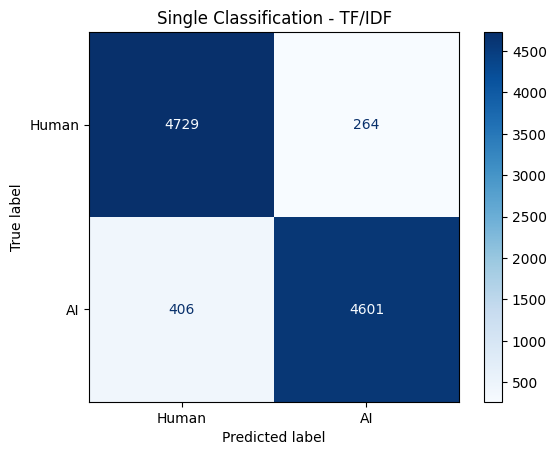

0.933
0.9338467614533965


In [ ]:
#Logistic Regression Classifier

preds = model.predict(single_df_X_test)
acc = accuracy_score(single_df_y_test, preds)
f1 = f1_score(single_df_y_test, preds, pos_label="ai")

ConfusionMatrixDisplay.from_predictions(
    single_df_y_test,
    preds,
    display_labels=["Human", "AI"],
    cmap="Blues",
    values_format="d"
)

#Confusion Matrix

plt.title("Single Classification - TF/IDF")
plt.show()

print(acc)
print(f1)

Display of words with the highest weight towards Human in Linear Regression classifier

In [ ]:
feature_names = np.array(model.named_steps["tfidf"].get_feature_names_out())
coefs = model.named_steps["lr"].coef_[0]

In [ ]:
#

top_human = pd.DataFrame({
    "word": feature_names,
    "coef": coefs
}).sort_values("coef", ascending=False).head(20)

top_human.head(20)

,word,coef
289245,you,3.180693
226852,that,2.751891
126366,it,2.192768
212110,so,1.730949
121466,is,1.657330
247783,there,1.459818
102879,have,1.420648
249406,they,1.257920
131860,just,1.185343
180161,people,1.119786


Display of words with the highest weight towards AI in Linear Regression classifier

In [ ]:
top_ai = pd.DataFrame({
    "word": feature_names,
    "coef": coefs
}).sort_values("coef")

top_ai.head(20)

,word,coef
10857,and,-2.146885
167692,often,-1.489763
248482,these,-1.059212
72539,due to,-0.908364
72532,due,-0.905769
83576,factors,-0.887476
252062,this,-0.794416
135249,leading,-0.779598
135263,leading to,-0.773104
172315,or,-0.748757


## FastText

A technique that uses pre-computed 300 dimensional embeddings to give a semantic representation for each word, and then uses these embeddings as inputs to a linear classifier.

FastText embeddings from Imports section must be downloaded for this section.

In [ ]:
def fasttext_embed(text, model):
    words = text.split() #split by word
    if not words:
        return np.zeros(model.get_dimension()) #return blank if empty
    return np.mean([model.get_word_vector(w) for w in words], axis=0) #else get vector for each word

#load embedding storage
ft = fasttext.load_model('cc.en.300.bin')

#Compute embeddings
single_df_X_train = np.vstack(single_df_X_train.apply(lambda t: fasttext_embed(t, ft)))
single_df_y_train = single_df_y_train.values

single_df_X_test = np.vstack(single_df_X_test.apply(lambda t: fasttext_embed(t, ft)))
single_df_y_test = single_df_y_test.values

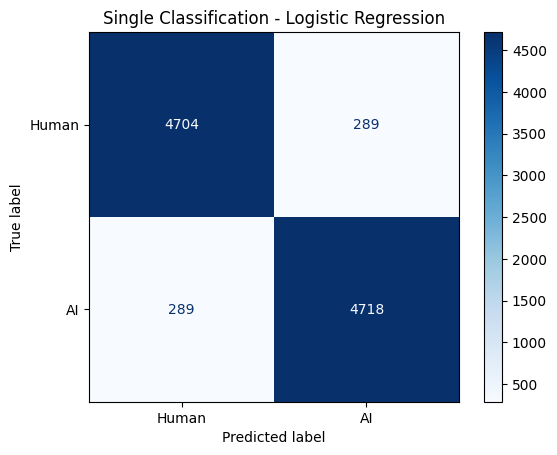

0.9422
0.9421189665531744


In [ ]:
# Fit and Predict Linear Classifier

lr = LogisticRegression(
    max_iter=4000,
    n_jobs=-1,
    C=0.9
)

# Fit Logistic Regressor
lr.fit(single_df_X_train, single_df_y_train)

# Predict and compute metrics
preds = lr.predict(single_df_X_test)
acc = accuracy_score(single_df_y_test, preds)
f1 = f1_score(single_df_y_test, preds, pos_label='ai')

ConfusionMatrixDisplay.from_predictions(
    single_df_y_test,
    preds,
    display_labels=["Human", "AI"],
    cmap="Blues",
    values_format="d"
)

plt.title("Single Classification - Logistic Regression")
plt.show()

print(acc)
print(f1)

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(single_df_X_train, single_df_y_train)
single_df_X_train = pd.DataFrame(single_df_X_train)
weights = pd.Series(
    lda.coef_[0],
    index=single_df_X_train.columns
).sort_values(key=np.abs, ascending=False)

display(weights)

,0
136,56.772285
273,54.879364
27,44.534119
19,44.229950
44,43.402695
4,-43.095711
6,42.536797
234,40.868347
113,-40.234779
18,-38.199787


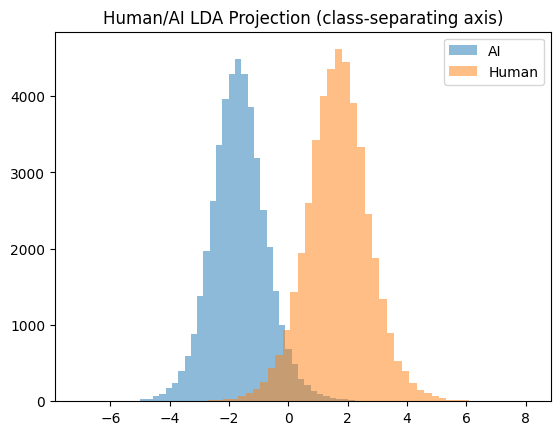

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(single_df_X_train, single_df_y_train)

plt.hist(X_lda[single_df_y_train == "ai"], bins=50, alpha=0.5, label="AI")
plt.hist(X_lda[single_df_y_train == "human"], bins=50, alpha=0.5, label="Human")
plt.legend()
plt.title("Human/AI LDA Projection (class-separating axis)")
plt.show()

## BERT

A model using a pre-trained transformer architecture (already trained on a vast corpus of human language) which is fine-tuned on the given dataset, and is then used to predict unseen responses

In [ ]:
# Input Tokenisation Function

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
#Classifier Initialisation
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# Classifier Setup
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Evaluation Metric Setup
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return accuracy.compute(predictions=preds, references=labels)

# Convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df_bert)
eval_dataset = Dataset.from_pandas(test_df_bert)

# Apply tokenization to the datasets
tokenized_train_dataset = train_dataset.map(tokenize, batched=True)
tokenized_eval_dataset = eval_dataset.map(tokenize, batched=True)

# Begin Training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_eval_dataset,
    processing_class=tokenizer,
    compute_mBetrics=compute_metrics
)

trainer.train()

Map:   0%|          | 0/90000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

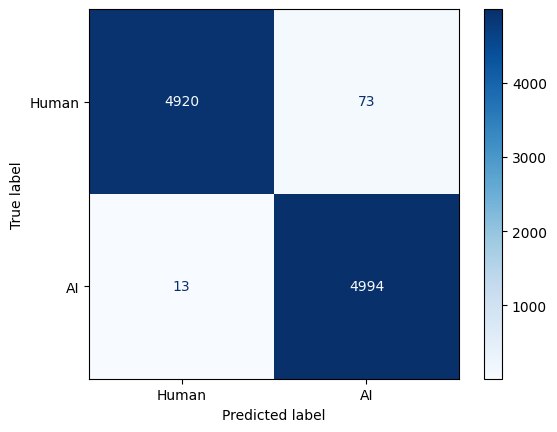

In [ ]:
# Output Confusion Matrix
pred = trainer.predict(tokenized_eval_dataset)
y_pred = pred.predictions.argmax(axis=1)
y_true = pred.label_ids
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"],

).plot(cmap="Blues")

#Classifiers - Pairwise

These classifiers are the same as the previous, but different from before, they are each given two responses with a label that represents the order of responses as Human/AI or as AI/Human.

## TF/IDF

A technique that computes a score of importance for every single word of Text Frequency (frequency of a word within a single document) relative to Inverse Document Frequency (chance of a word appearing within any document), which then uses these scores to classify using a linear classifier.

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

tfidf.fit(
    pd.concat([pair_df_train["A"], pair_df_train["B"]])
)

TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2), sublinear_tf=True)

In [ ]:
X_train = (
    tfidf.transform(pair_df_train["A"]) -
    tfidf.transform(pair_df_train["B"])
)

X_test = (
    tfidf.transform(pair_df_test["A"]) -
    tfidf.transform(pair_df_test["B"])
)

y_train = pair_df_train["label"].values
y_test = pair_df_test["label"].values

In [ ]:
clf = LogisticRegression(
    max_iter=2000,
    C=1.0
)

clf.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

Accuracy: 0.9957


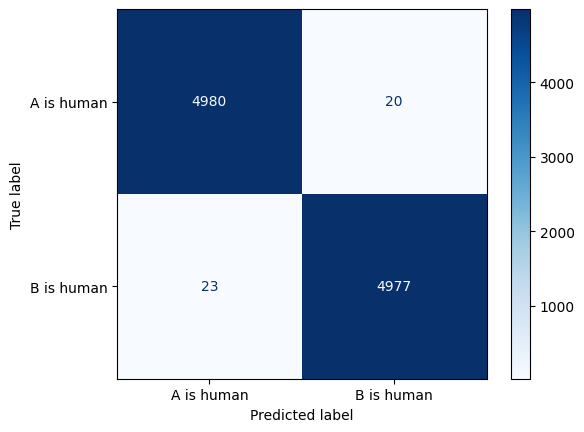

In [ ]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["A is human", "B is human"]
).plot(cmap="Blues")

## FastText + Logistic Regression

A technique that uses pre-computed 300 dimensional embeddings to give a semantic representation for each word, and then uses these embeddings as inputs to a linear classifier.

FastText embeddings from Imports section must be downloaded for this section.

In [ ]:
def fasttext_embed(text, model):
    words = text.split()
    if not words:
        return np.zeros(model.get_dimension())
    return np.mean([model.get_word_vector(w) for w in words], axis=0)

ft = fasttext.load_model('cc.en.300.bin')

#Applying embedding transformation to A and B columns
A_emb = np.vstack(pair_df_train["A"].apply(lambda t: fasttext_embed(t, ft)))
B_emb = np.vstack(pair_df_train["B"].apply(lambda t: fasttext_embed(t, ft)))

# X data is the difference between A and B columns, which is used to train the classifier
X_train = A_emb - B_emb
y_train = pair_df_train["label"].values

A_emb_test = np.vstack(pair_df_test["A"].apply(lambda t: fasttext_embed(t, ft)))
B_emb_test = np.vstack(pair_df_test["B"].apply(lambda t: fasttext_embed(t, ft)))

X_test = A_emb_test - B_emb_test
y_test = pair_df_test["label"].values

#Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Train linear classifier
clf = LogisticRegression(
    max_iter=5000,
    C=1
)

clf.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=5000)

Accuracy: 0.9917


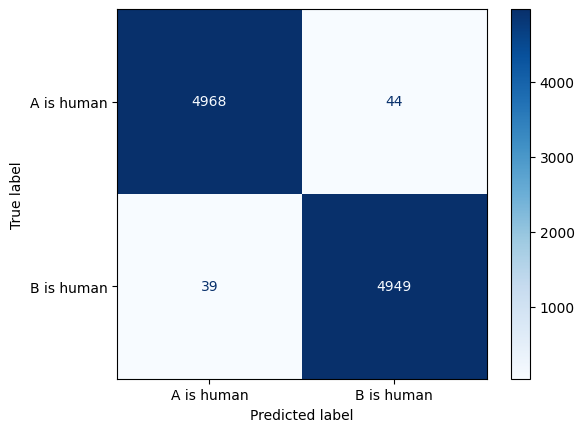

In [ ]:
#predict and output metrics
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["A is human", "B is human"]
).plot(cmap="Blues")

## BERT

A model using a pre-trained transformer architecture (already trained on a vast corpus of human language) which is fine-tuned on the given dataset, and is then used to predict unseen responses

In [ ]:
# Input Tokenisation Function
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["A"],
        batch["B"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Convert to Hugging Face
train_ds = Dataset.from_pandas(pair_df_train[["A", "B", "label"]])
val_ds   = Dataset.from_pandas(pair_df_test[["A", "B", "label"]])
# Tokenise
train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
# Remove column names
train_ds = train_ds.remove_columns(["A", "B"])
val_ds   = val_ds.remove_columns(["A", "B"])
# convert to torch
train_ds = train_ds.with_format("torch")
val_ds   = val_ds.with_format("torch")

Map:   0%|          | 0/90000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./pairwise_bert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,                # if GPU supports it
    report_to="none"
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=preds, references=labels)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipython-input-4200851939.py:8: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.006400,0.019177,0.996100
2,0.009200,0.007948,0.998400
3,0.000000,0.008333,0.998700


TrainOutput(global_step=16875, training_loss=0.03553948893017239, metrics={'train_runtime': 1767.8987, 'train_samples_per_second': 152.724, 'train_steps_per_second': 9.545, 'total_flos': 1.788309881856e+16, 'train_loss': 0.03553948893017239, 'epoch': 3.0})

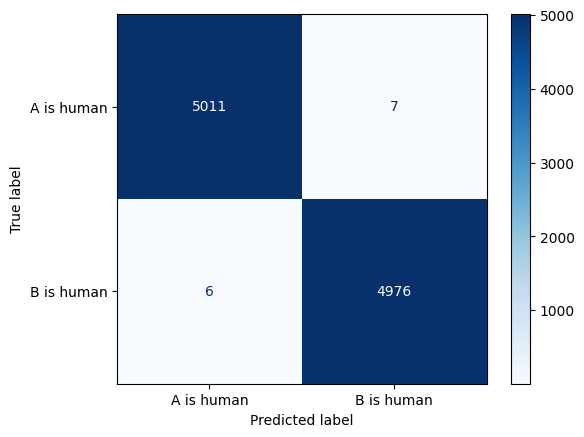

In [ ]:
pred = trainer.predict(val_ds)
y_pred = pred.predictions.argmax(axis=1)
y_true = pred.label_ids

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["A is human", "B is human"]
).plot(cmap="Blues")

#Haiku Evaluation Set - Single

This section is trained on single responses from Gemini 2.0 Flash, but is then evaluated on responses from Claude 3 Haiku in order to test generalisation on single classification between generative AI models

##TF-IDF

A technique that computes a score of importance for every single word of Text Frequency (frequency of a word within a single document) relative to Inverse Document Frequency (chance of a word appearing within any document), which then uses these scores to classify using a linear classifier.

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        min_df=5,
        max_df=0.9
    )),
    ("lr", LogisticRegression(max_iter=5000, C=0.01))
])

model.fit(single_df_X_train, single_df_y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 3))),
                ('lr', LogisticRegression(C=0.01, max_iter=5000))])

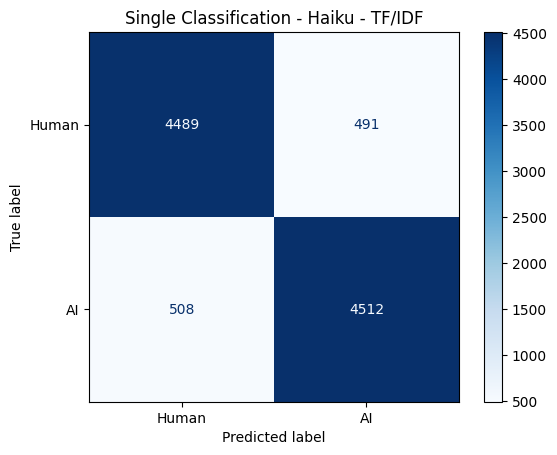

0.9001
0.8998697003107147


In [ ]:
preds = model.predict(haiku_single_X)
acc = accuracy_score(haiku_single_y, preds)
f1 = f1_score(haiku_single_y, preds, pos_label="ai")

ConfusionMatrixDisplay.from_predictions(
    haiku_single_y,
    preds,
    display_labels=["Human", "AI"],
    cmap="Blues",
    values_format="d"
)

plt.title("Single Classification - Haiku - TF/IDF")
plt.show()

print(acc)
print(f1)

## FastText

A technique that uses pre-computed 300 dimensional embeddings to give a semantic representation for each word, and then uses these embeddings as inputs to a linear classifier.

FastText embeddings from Imports section must be downloaded for this section.

In [ ]:
def fasttext_embed(text, model):
    words = text.split()
    if not words:
        return np.zeros(model.get_dimension())
    return np.mean([model.get_word_vector(w) for w in words], axis=0)

ft = fasttext.load_model('cc.en.300.bin')

single_df_X_train = np.vstack(single_df_X_train.apply(lambda t: fasttext_embed(t, ft)))
single_df_y_train = single_df_y_train.values

haiku_single_X = np.vstack(haiku_single_X.apply(lambda t: fasttext_embed(t, ft)))
haiku_single_y = haiku_single_y.values

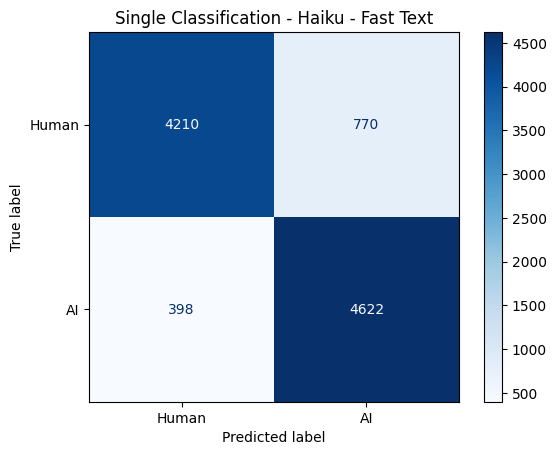

0.8832
0.8781810596579057


In [ ]:
lr = LogisticRegression(
    max_iter=4000,
    n_jobs=-1,
    C=0.9
)

lr.fit(single_df_X_train, single_df_y_train)

preds = lr.predict(haiku_single_X)
acc = accuracy_score(haiku_single_y, preds)
f1 = f1_score(haiku_single_y, preds, pos_label='ai')

ConfusionMatrixDisplay.from_predictions(
    haiku_single_y,
    preds,
    display_labels=["Human", "AI"],
    cmap="Blues",
    values_format="d"
)

plt.title("Single Classification - Haiku - Fast Text")
plt.show()

print(acc)
print(f1)

## BERT

A model using a pre-trained transformer architecture (already trained on a vast corpus of human language) which is fine-tuned on the given dataset, and is then used to predict unseen responses

In [ ]:
# Input Tokenisation Function
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return accuracy.compute(predictions=preds, references=labels)

# Convert pandas DataFrames to Hugging Face Dataset objects
# These DataFrames (train_df_bert, test_df_bert) should now have 'text' and 'labels' columns with reset indices.
train_dataset = Dataset.from_pandas(train_df_bert)
eval_dataset = Dataset.from_pandas(haiku_bert)

# Apply tokenization to the datasets
tokenized_train_dataset = train_dataset.map(tokenize, batched=True)
tokenized_eval_dataset = eval_dataset.map(tokenize, batched=True)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_eval_dataset,
    processing_class=tokenizer, # Changed from tokenizer to processing_class
    compute_metrics=compute_metrics
)

Map:   0%|          | 0/87030 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Epoch,Training Loss,Validation Loss,Accuracy
1,0.034000,0.106533,0.976000
2,0.031600,0.120436,0.973000
3,0.004900,0.160995,0.973100


TrainOutput(global_step=16320, training_loss=0.038725178118272426, metrics={'train_runtime': 5993.0182, 'train_samples_per_second': 43.566, 'train_steps_per_second': 2.723, 'total_flos': 1.729295655754752e+16, 'train_loss': 0.038725178118272426, 'epoch': 3.0})

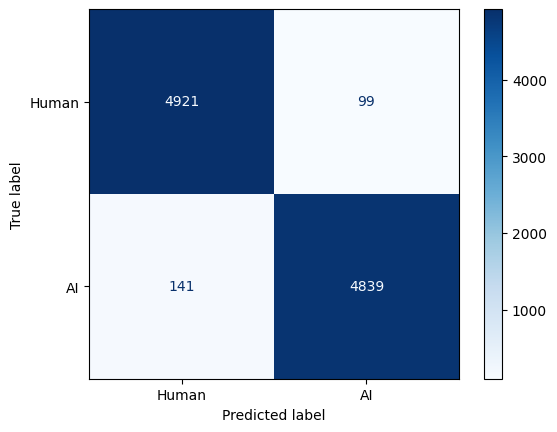

In [ ]:
pred = trainer.predict(tokenized_eval_dataset)
y_pred = pred.predictions.argmax(axis=1)
y_true = pred.label_ids
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"],

).plot(cmap="Blues")

# Haiku Evaluation Set - Pairwise

This section is trained on pairwise responses from Gemini 2.0 Flash, but is then evaluated on responses from Claude 3 Haiku in order to test generalisation on pairwise classification between generative AI models

## TF-IDF

A technique that computes a score of importance for every single word of Text Frequency (frequency of a word within a single document) relative to Inverse Document Frequency (chance of a word appearing within any document), which then uses these scores to classify using a linear classifier.

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

tfidf.fit(
    pd.concat([pair_df_train["A"], pair_df_train["B"]])
)

TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2), sublinear_tf=True)

In [ ]:
X_train = (
    tfidf.transform(pair_df_train["A"]) -
    tfidf.transform(pair_df_train["B"])
)

X_test = (
    tfidf.transform(haiku_pair_df["A"]) -
    tfidf.transform(haiku_pair_df["B"])
)

y_train = pair_df_train["label"].values
y_test = haiku_pair_df["label"].values

In [ ]:
clf = LogisticRegression(
    max_iter=4000,
    C=1.0
)

clf.fit(X_train, y_train)

LogisticRegression(max_iter=4000)

Accuracy: 0.9738


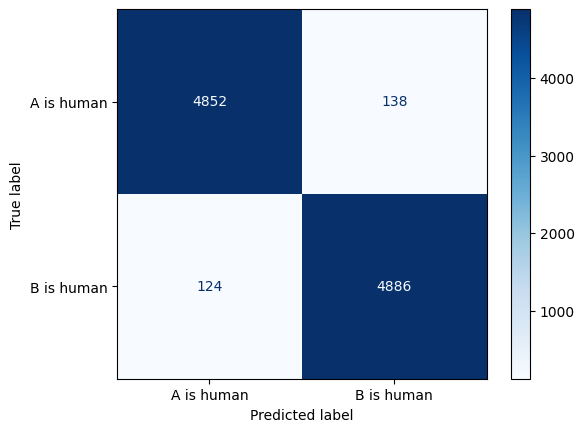

In [ ]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["A is human", "B is human"]
).plot(cmap="Blues")

## FastText

A technique that uses pre-computed 300 dimensional embeddings to give a semantic representation for each word, and then uses these embeddings as inputs to a linear classifier.

FastText embeddings from Imports section must be downloaded for this section.

In [ ]:
def fasttext_embed(text, model):
    words = text.split()
    if not words:
        return np.zeros(model.get_dimension())
    return np.mean([model.get_word_vector(w) for w in words], axis=0)

ft = fasttext.load_model('cc.en.300.bin')

A_emb = np.vstack(pair_df_train["A"].apply(lambda t: fasttext_embed(t, ft)))
B_emb = np.vstack(pair_df_train["B"].apply(lambda t: fasttext_embed(t, ft)))

X_train = A_emb - B_emb
y_train = pair_df_train["label"].values

A_emb_test = np.vstack(haiku_pair_df["A"].apply(lambda t: fasttext_embed(t, ft)))
B_emb_test = np.vstack(haiku_pair_df["B"].apply(lambda t: fasttext_embed(t, ft)))

X_test = A_emb_test - B_emb_test
y_test = haiku_pair_df["label"].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
clf = LogisticRegression(
    max_iter=4000,
    C=1
)

clf.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=4000)

Accuracy: 0.9738


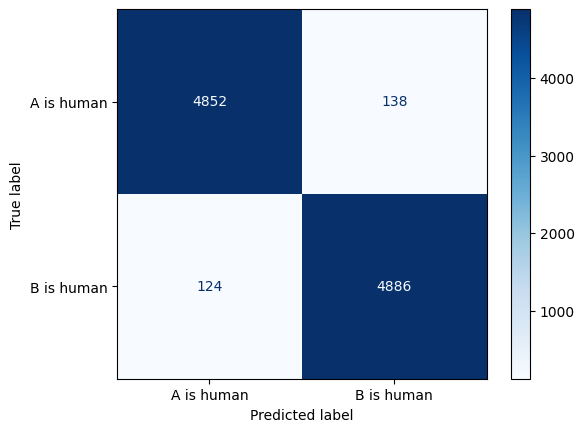

In [ ]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["A is human", "B is human"]
).plot(cmap="Blues")

##BERT

A model using a pre-trained transformer architecture (already trained on a vast corpus of human language) which is fine-tuned on the given dataset, and is then used to predict unseen responses

In [ ]:
# Input Tokenisation Function
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["A"],
        batch["B"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
train_ds = Dataset.from_pandas(pair_df_train[["A", "B", "label"]])
val_ds   = Dataset.from_pandas(haiku_pair_df[["A", "B", "label"]])

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["A", "B"])
val_ds   = val_ds.remove_columns(["A", "B"])

train_ds = train_ds.with_format("torch")
val_ds   = val_ds.with_format("torch")

Map:   0%|          | 0/87030 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./pairwise_bert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    report_to="none"
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=preds, references=labels)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipython-input-4200851939.py:8: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.018900,0.028847,0.993200
2,0.007800,0.050445,0.991300
3,0.000000,0.048453,0.993300


TrainOutput(global_step=16320, training_loss=0.030972437174561634, metrics={'train_runtime': 1004.5563, 'train_samples_per_second': 259.906, 'train_steps_per_second': 16.246, 'total_flos': 1.729295655754752e+16, 'train_loss': 0.030972437174561634, 'epoch': 3.0})

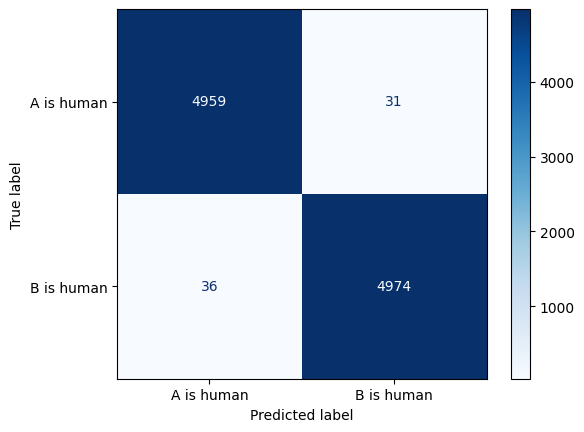

In [ ]:
pred = trainer.predict(val_ds)
y_pred = pred.predictions.argmax(axis=1)
y_true = pred.label_ids

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["A is human", "B is human"]
).plot(cmap="Blues")